<a href="https://colab.research.google.com/github/Muku2003-code/Muku2003-code/blob/main/Global_Cybersecurity_Threats_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plotting
%matplotlib inline

# Set style
sns.set(style='whitegrid')

# **Data Loading**

We load the dataset containing global cybersecurity threats from 2015 to 2024.



In [3]:
# Load the Dataset
file_path = "/content/Global_Cybersecurity_Threats_2015-2024.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   Country  Year        Attack Type     Target Industry  \
0    China  2019           Phishing           Education   
1    China  2019         Ransomware              Retail   
2    India  2017  Man-in-the-Middle                  IT   
3       UK  2024         Ransomware  Telecommunications   
4  Germany  2018  Man-in-the-Middle                  IT   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                          80.53                    773169  Hacker Group   
1                          62.19                    295961  Hacker Group   
2                          38.65                    605895  Hacker Group   
3                          41.44                    659320  Nation-state   
4                          74.41                    810682       Insider   

  Security Vulnerability Type Defense Mechanism Used  \
0          Unpatched Software                    VPN   
1          Unpatched Software               Firewall   
2              Weak 

# **Data Exploration**

Before diving into the analysis, we take a look at the structure of the data, inspect the data types and look for any missing values.

In [ ]:
# General information about the dataset
df.info()

# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# Statistical summary for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB
Missing values in each column:
Countr

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


# **Data Cleaning and Preprocessing**

In this section, we will:

*   Handle any potential missing values
*  Encode categorical variables where necessary

*   Convert any columns with date information (if applicable) to proper datetime types.
* In this dataset, the 'Year' column is provided as an integer and does not
require conversion.




In [ ]:
# Handling missing values
# In this case, we choose to fill missing numeric values with their median and categorical values with the mode.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# Confirm that missing values have been handled
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64



# **Exploratory Data Analysis**

* In our exploratory analysis, we will visualize various aspects of the data using several techniques.
* We provide histograms for numerical distributions, count plots (pie charts & bar plots) for categorical frequencies, heatmaps for correlations, and more advanced visualizations such as pair plots.
* We choose to focus on key features like 'Year', 'Financial Loss (in Million $)', 'Number of Affected Users', and 'Incident Resolution Time (in Hours)



# **Histogram (for numeric features)**

* Purpose: Shows the distribution of numeric data like financial loss, affected users, etc.

* Helps detect outliers and skewed values.

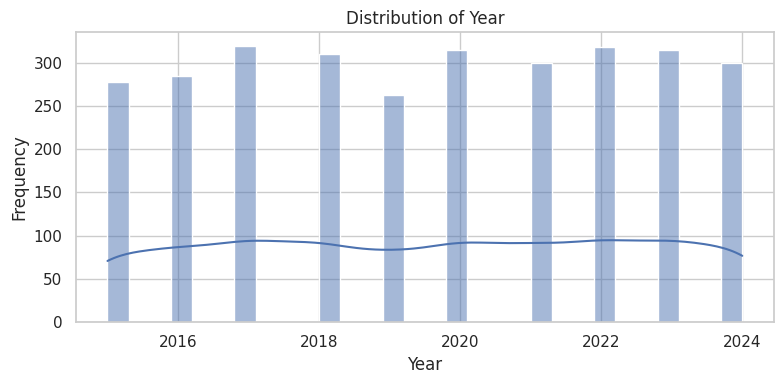

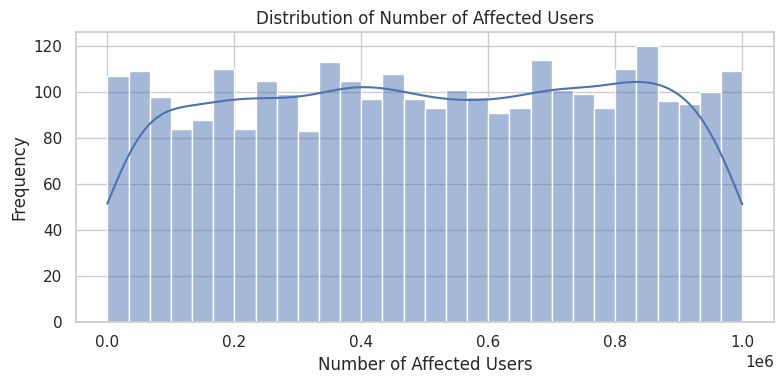

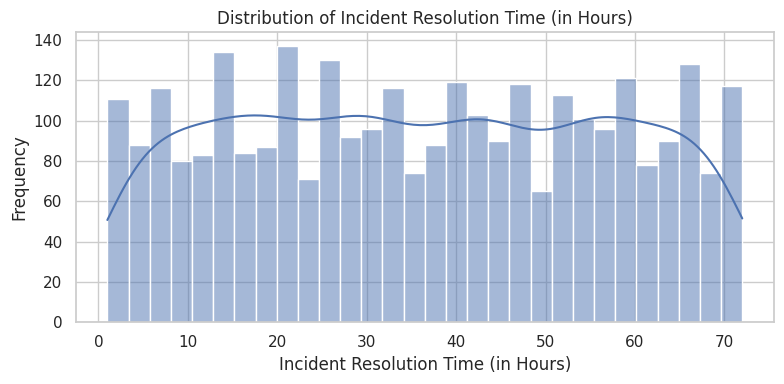

In [ ]:
# 1. Distribution of Numeric Features
numeric_cols = ['Year', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# **Financial Loss Over Years (Line Plot)**

* Purpose: Visualizes how total financial loss has changed year by year.

* Helps identify increasing threat trends over time.

<ipython-input-7-f6e242d82b70>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Year', y='Financial Loss (in Million $)', estimator='sum', ci=None, marker='o')


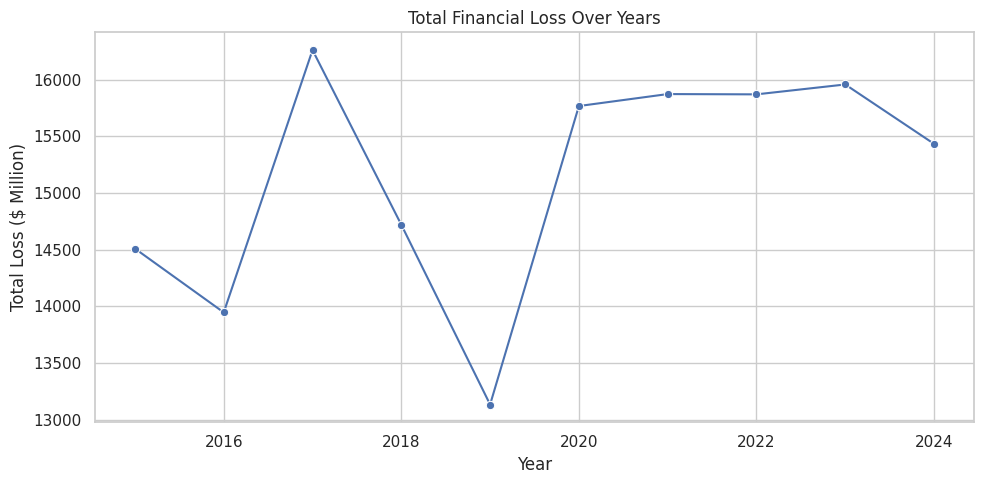

In [ ]:
# 2. Financial Loss over the Years
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Financial Loss (in Million $)', estimator='sum', ci=None, marker='o')
plt.title('Total Financial Loss Over Years')
plt.ylabel('Total Loss ($ Million)')
plt.tight_layout()
plt.show()

#**Top 10 Countries by Incidents (Bar Plot)**

* Purpose: Highlights which countries face the most attacks.

* Useful for geographical threat analysis.

<ipython-input-8-7b99441b6b56>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


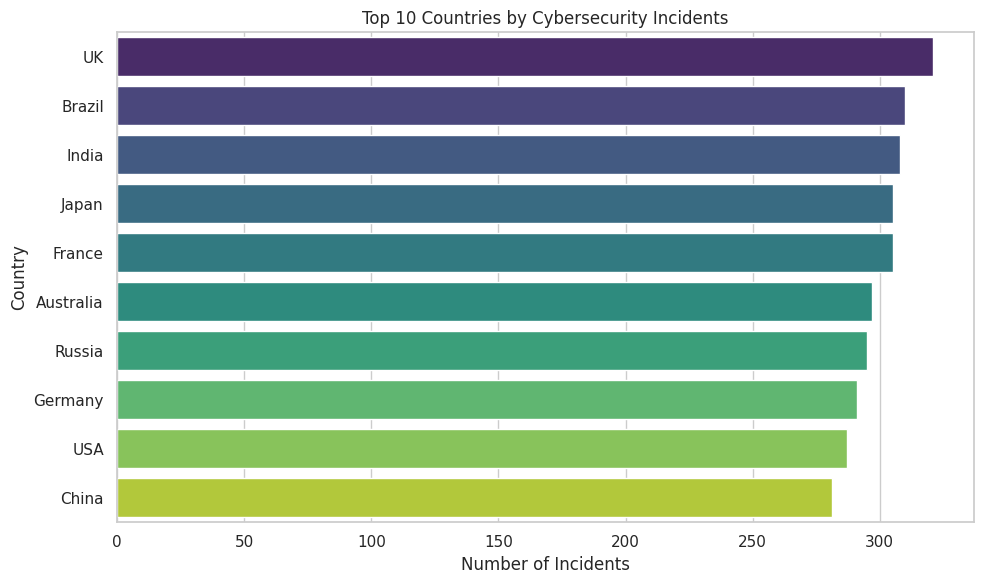

In [ ]:
# 3. Top 10 Countries by Number of Incidents
plt.figure(figsize=(10, 6))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Cybersecurity Incidents')
plt.xlabel('Number of Incidents')
plt.tight_layout()
plt.show()

#**Threat Types Over Years (Stacked Bar Plot)**
* Purpose: Tracks how attack types evolved year by year.

* Helps spot trends in cybercrime methods.

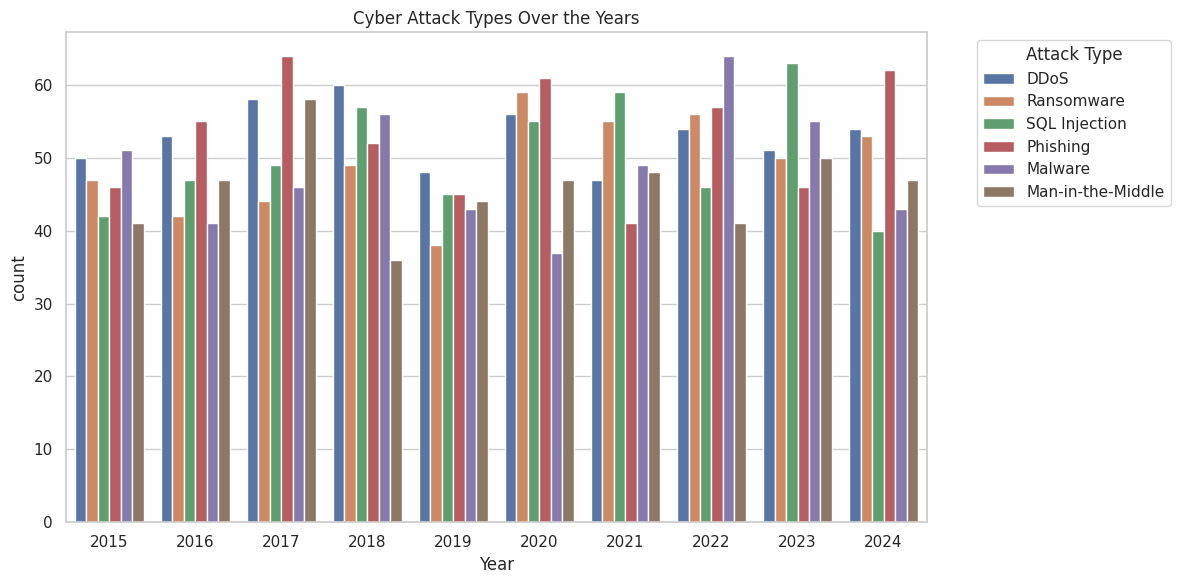

In [ ]:
# 8. Threat Types Over Years
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Year', hue='Attack Type')
plt.title('Cyber Attack Types Over the Years')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


 # **Correlation Heatmap**
* Purpose: Shows relationships between numeric features.

Example: More affected users might relate to higher financial loss

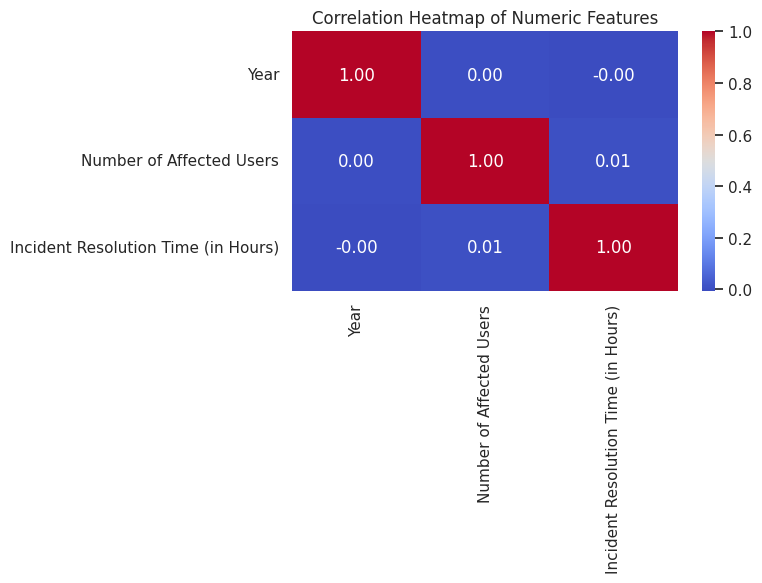

In [ ]:

# 5. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()